## Long short-term memory (LSTM) RNN in Tensorflow


Long Short-Term Memory (LSTM) where designed to address the vanishing gradient issue faced by traditional RNNs in learning from long-term dependencies in sequential data. LSTMs are capable of maintaining information over extended periods because of memory cells and gating mechanisms. These memory cells are managed by three primary gates: the input gate, the forget gate and the output gate.

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### 2. Data Loading, Preparing and Scaling

Here we are using a dataset of monthly milk production using LSTM.


In [2]:
dataset = "https://raw.githubusercontent.com/itsluckysharma01/Datasets/refs/heads/main/monthly_milk_production.csv" 

data = pd.read_csv(dataset)

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
production = data['Production'].astype(float).values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(production)

In [3]:
data

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


In [4]:
data.shape

(168, 1)

### 3. Creating Sequences and Train-Test Split


In [5]:
window_size = 12
X = []
y = []
target_dates = data.index[window_size:]

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i - window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, target_dates, test_size=0.2, shuffle=False
)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

### 4. Building the LSTM Model

This step involves defining and building the LSTM model architecture.

In [6]:
model = Sequential()
model.add(LSTM(units=128, return_sequences=True,
          input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

c:\Users\PANDIT JI\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 5. Training and Evaluating the Model 

In this step, we train the model on the training data and evaluate its performance.

In [7]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1)

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

rmse = np.sqrt(np.mean((y_test - predictions)**2))
print(f'RMSE: {rmse:.2f}')

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 225ms/step - loss: 0.1804 - val_loss: 0.0356
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0278 - val_loss: 0.0528
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0360 - val_loss: 0.0528
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0339 - val_loss: 0.0593
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0293 - val_loss: 0.0267
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0272 - val_loss: 0.0289
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0276 - val_loss: 0.0307
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0241 - val_loss: 0.0438
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0279 - val_loss: 0.0330
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0254 - val_loss: 0.0258
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0223 - val_loss: 0.0255
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0238 - val_l

### 6. Visualizing Model Performance

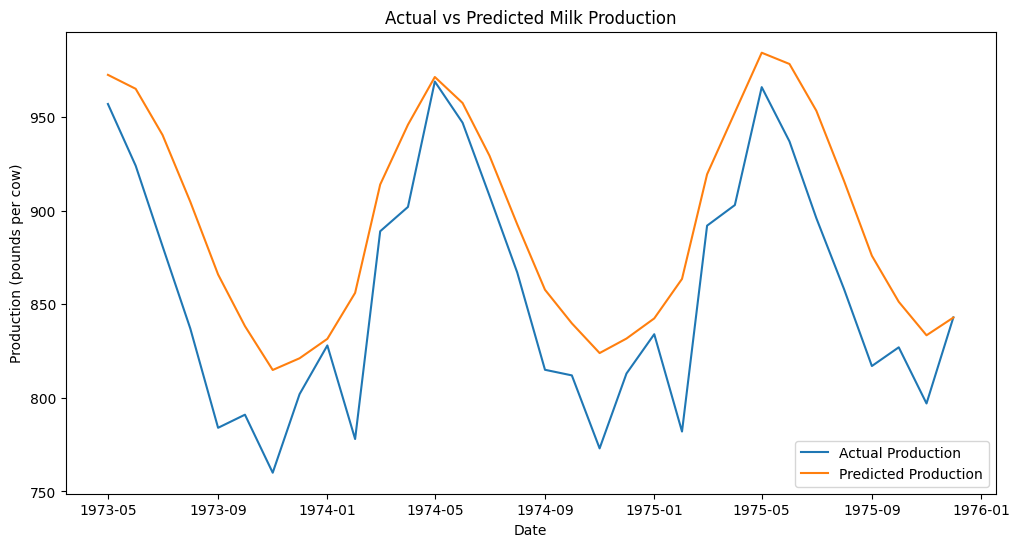

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(dates_test, y_test, label='Actual Production')
plt.plot(dates_test, predictions, label='Predicted Production')
plt.title('Actual vs Predicted Milk Production')
plt.xlabel('Date')
plt.ylabel('Production (pounds per cow)')
plt.legend()
plt.show()

The LSTM model successfully captures the trends and patterns in the time series data. As observed, the predicted values closely follow the actual values with small variations during transitions between peaks and lows. This demonstrates the effectiveness of LSTM for time series prediction tasks such as forecasting milk production.